<a href="https://colab.research.google.com/github/LOVELY1907/SAP_AI-ML-DL/blob/main/01_Data_Preprocessing/data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/employee_preprocessing_dataset_700_with_nulls.csv")

In [ ]:
df.head(10)

,age,salary,experience_years,performance_score,gender,department,education_level
0,33.973713,195541.0,26.000000,8.586609,Male,Finance,Bachelor
1,28.893886,216983.0,27.000000,6.941626,Female,Finance,High School
2,35.181508,270747.0,36.000000,7.614068,Male,IT,High School
3,42.184239,235103.0,32.000000,8.520324,Male,HR,PhD
4,28.126773,175566.0,NaN,8.968353,Female,IT,PhD
5,28.126904,223193.0,2.972820,4.314138,Male,Marketing,Master
6,42.633703,291417.0,0.312757,2.279503,Male,Finance,High School
7,36.139478,271015.0,12.005335,3.510714,Female,Sales,Master
8,26.244205,280956.0,4.709281,2.737105,Female,Sales,Bachelor
9,34.340480,220744.0,4.996668,3.482550,Female,Finance,Diploma


In [ ]:
df.isnull().sum()

,0
age,35
salary,35
experience_years,35
performance_score,35
gender,0
department,0
education_level,0


In [ ]:
df['age'] = df['age'].fillna(df['age'].mean())
df['salary'] = df['salary'].fillna(df['salary'].mean())
df['experience_years'] = df['experience_years'].fillna(df['experience_years'].mean())

In [ ]:
df.shape

(700, 7)

In [ ]:
df.isnull().sum()

,0
age,0
salary,0
experience_years,0
performance_score,35
gender,0
department,0
education_level,0


In [ ]:
df['age'] = df['age'].fillna(df['age'].median())
df['salary'] = df['salary'].fillna(df['salary'].median())
df['experience_years'] = df['experience_years'].fillna(df['experience_years'].median())

In [ ]:
df.isnull().sum()

,0
age,0
salary,0
experience_years,0
performance_score,35
gender,0
department,0
education_level,0


<Axes: >

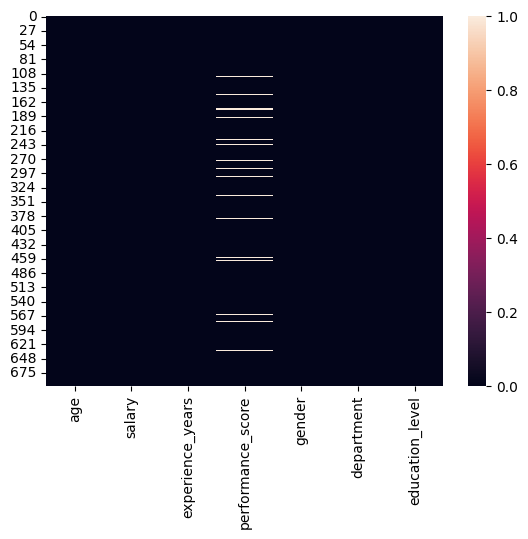

In [ ]:
#finding out The null values
sns.heatmap(df.isnull())

In [ ]:
from sklearn.preprocessing import OneHotEncoder

#object
ohe = OneHotEncoder(sparse_output=False)
df['gender'] = ohe.fit_transform(df[['gender']])

In [ ]:
df['gender']

,gender
0,0.0
1,1.0
2,0.0
3,0.0
4,1.0
...,...
695,0.0
696,0.0
697,0.0
698,0.0


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

education_categories = ['High School','Diploma','Bachelor','Master','PhD']
od = OrdinalEncoder(categories=[education_categories])
df['education_level'] = od.fit_transform(df[['education_level']])

In [ ]:
df['education_level']

,education_level
0,2.0
1,0.0
2,0.0
3,4.0
4,4.0
...,...
695,0.0
696,3.0
697,1.0
698,4.0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['department'] = le.fit_transform(df['department'])

In [ ]:
df.head(4)

,age,salary,experience_years,performance_score,gender,department,education_level
0,33.973713,195541.0,26.0,8.586609,0.0,0,2.0
1,28.893886,216983.0,27.0,6.941626,1.0,0,0.0
2,35.181508,270747.0,36.0,7.614068,0.0,2,0.0
3,42.184239,235103.0,32.0,8.520324,0.0,1,4.0


In [ ]:
Q3 = df['salary'].quantile(0.75)
Q1 = df['salary'].quantile(0.25)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
print(lower_bound)
print(upper_bound)

24276.217525944874
97897.6561793882


In [ ]:
# filter
df_with_outliers = df[(df['salary'] > upper_bound) | (df['salary'] < lower_bound)]

In [ ]:
len(df_with_outliers)

20